# The Quarterly Refunding Shock — a quantitative teardown 🔬
### 106 hardcoded QRA dates · FOMC decontamination · Welch day-0 tests + random-calendar placebo · the first-Friday collision · a vol-normalised 2023 era split · TLT costs · synthetic power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2023_regime_change%3F: Busted](https://img.shields.io/badge/2023_regime_change%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — *the Quarterly Refunding Announcement moves the long end; 2023 made QRA-day a macro event* — is tested on the full official announcement record against ^TNX/^TYX daily yield changes and TLT.

> ⚠️ **Data note.** Event table: 106 QRA dates 2000→2026, derived once from TreasuryDirect TA_WS (`announcementDate` of the refunding securities) and hardcoded with source; all Wednesdays 08:30 ET. Tape: yfinance ^TNX/^TYX (yield in %), TLT total-return, cached, as-of 2026-06-30. No survivorship (full official record, constant-maturity indices). Fingerprints `07c63093f8d2` / `0f37876ddb3a` / `ef0fdae90551`; numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quarterly_refunding_shock import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TNX, TYX, TLT = data.load_real()
    DY = st.dy_bps(TNX)
    LIDX = pd.DatetimeIndex(TNX.index)
    SP = st.clean_split(LIDX, data.QRA_DATES, data.FOMC_DATES)
    CLEAN = st.align_positions(LIDX, DY.index, SP["clean_pos"])
    ALLQ = st.align_positions(LIDX, DY.index, SP["qra_pos"])
    BASE = SP["base_mask"][1:]
else:
    TNX = TYX = TLT = DY = None
print("real cache present:", HAVE_REAL, "| QRA dates:", len(data.QRA_DATES))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_qra': 106, 'first': '2000-02-02', 'last': '2026-05-06', 'n_clean': 69, 'n_overlap': 37, 'overlap_pct': 35, 'n_base': 5936, 'day0_clean': (69, 3.86, 4.28, 0.9, -1.12, 0.03, 0.05), 'day0_all': (106, 3.91, 4.28, 0.91, -1.18, -0.3, -0.61), 'day0_overlap': (37, 4.02, 4.28, 0.94, -0.48, -0.91, -1.08), 'fomc_only': (175, 5.17, 1.21, 2.24), 'placebo_p': 0.823, 'placebo_draw_mean': 4.27, 'y30': (4.37, 3.97, 1.1, 0.73, 0.1, 0.13), 'window': [(-1, 4.67, 0.91, -0.25, -0.35), (0, 3.86, -1.12, 0.03, 0.05), (1, 3.99, -0.69, -0.77, -1.23), (2, 6.42, 4.1, 2.17, 2.41), (3, 3.49, -1.72, 0.48, 0.77)], 'jobs': {'n_day2': 69, 'n_ff': 63, 'share_pct': 91, 'abs_all': 6.42, 'welch_all': 4.1, 'abs_ff': 6.62, 'abs_ex': 4.3, 'welch_ex': 0.01, 'n_ex': 6}, 'era_all': {'early': 0.9, 'n_early': 92, 'late': 1.17, 'n_late': 14, 'welch': 1.21, 'trim': 1.2, 'n_trim': 12, 'welch_trim': 1.16}, 'era_clean': {'early': 0.95, 'n_early': 62, 'late': 0.99, 'n_late': 7, 'welch': 0.1, 'trim': 1.07, 'n_trim': 6, 'welch_trim': 0.26}, 'episodes': [('2023-07-31', 'borrowing estimate (+$274B surprise)', -1.0), ('2023-08-02', 'QRA statement (sizes up; Fitch downgrade eve)', 2.7), ('2023-10-30', 'borrowing estimate ($76B below flag)', 3.0), ('2023-11-01', 'QRA statement (slower; same-day FOMC)', -8.6)], 'week_aug': 9.1, 'week_nov': -28.7, 'tlt': {'n': 96, 'uncond': -14.3, 'uncond_t': -0.89, 'base': 4.6, 'welch': -1.15, 'cond': -21.3, 'cond_t': -1.33, 'net': [(2.0, -18.3, -73, -25.3, -102), (5.0, -24.3, -97, -31.3, -126)]}, 'syn': [(1.0, 0.0, 1.08, 1.09, -0.91, -1.48), (2.0, 0.0, 2.17, 7.65, -1.81, -1.48), (1.0, 4.0, 1.19, 2.2, 3.09, 5.05)], 'fp_tnx': '07c63093f8d2', 'fp_tyx': '0f37876ddb3a', 'fp_tlt': 'ef0fdae90551'}


real cache present: True | QRA dates: 106


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Clean-QRA day-0 \|Δy10\| **3.86 bps** vs baseline **4.28** (×0.90, Welch *t* = **-1.12**), placebo **p = 0.82**; 30Y ×1.10 (*t* = +0.73). In-tape control: FOMC days ×1.21 at *t* = +2.24. |
| **Tradability** | `MIRAGE` | TLT day-0-close→+3: **-14.3 bps/event gross** (*t* = -0.89); sign-conditional **-21.3** (*t* = -1.33). Negative before costs. |
| **2023 regime change?** | `BUSTED` | Vol-normalised FOMC-clean QRA days: 2023+ **0.99×** own-era noise vs 0.95× pre-2023, Welch *t* = **+0.10** (n = 7, honest small-n). |

> 💡 In plain words: the announcement day is quieter than an average day, there is nothing to trade, and the 2023 legend rests on two loud *weeks* full of other catalysts.

## 1 · The claim, steelmanned

Let $d^{QRA}_t$ flag QRA statement days and $\Delta y_t$ the daily 10Y yield change (bps). The folklore's testable content:

- **H₁ (event-day volatility).** $E[|\Delta y_t|\,|\,d^{QRA}_t=1] > E[|\Delta y_t|\,|\,\text{ordinary}]$ — announcement surprises move the long end *on the day*.
- **H₂ (tradability).** The post-announcement drift (entered at the day-0 close — the one honest lag) is monetisable in TLT.
- **H₃ (the 2023 break).** The effect appeared/intensified in 2023 (the claim's own break date — not snooped).

Design hazards we must handle: **(a)** 35% of QRA Wednesdays are FOMC statement days (both calendars choose early-quarter Wednesdays); **(b)** day+2 of the window is the first-Friday **Employment Situation** slot 91% of the time; **(c)** n = 14 QRA days since 2023 — any era claim carries small-n error bars; **(d)** 2023's baseline vol was itself elevated, so era comparisons must be vol-normalised.

## 2 · So what? — the inference plan

Events sit ~63 trading days apart: event-day observations are serially uncorrelated, there are no overlapping windows, and the **Welch *t*** on $|\Delta y|$ (unequal variances — event n=69 vs baseline n≈5,900) is the appropriate robust statistic; HAC would be solving a problem this design doesn't have. Supplements: a **2,000-draw random-calendar placebo** (same event count, drawn from the baseline days — far beyond the desk's ≥20-seed floor for random baselines), a signed one-sample *t* (no direction prior — surprises cut both ways), the 30Y (^TYX) as the "long end proper" check, and an **in-tape positive control**: FOMC-only days pushed through the identical pipeline must fire, or the instrument is blind.

## 3 · How we'd know — the protocol

- **Events.** 106 QRA dates 2000-02-02 → 2026-05-06, hardcoded from TreasuryDirect TA_WS (the refunding securities' official `announcementDate` IS the QRA date; all Wednesdays, 08:30 ET; the 2023/2024 dates match the press archive).
- **Decontamination.** 37 of 106 QRA days (35%) are FOMC statement days → primary set = **69 FOMC-clean** QRA days; baseline = 5,936 sessions with no QRA-window day and no FOMC day.
- **Primary test.** Welch *t* on day-0 $|\Delta y_{10}|$, clean QRA vs baseline; placebo p from 2,000 random calendars; signed one-sample *t*.
- **Window.** Offsets −1..+3 with the first-Friday (jobs) collision check at +2.
- **Era split (H₃).** $|\Delta y|$ / trailing-60d mean $|\Delta y|$ (shifted — day-0 not in its own denominator), Welch late (2023+) vs early.
- **Tradability.** TLT, entry day-0 close (ONE lag), exit +3 close; non-overlapping baseline windows; 2/5 bps one-way × 2 legs.
- **Positive controls.** In-tape: FOMC days. Synthetic: planted event-day vol multiplier / signed mean vs the null (machinery proof only, never market evidence).

## 4 · The teardown

### 4a · Day-0: the event that isn't there

Clean QRA days vs baseline, with the FOMC-only in-tape control alongside, and the random-calendar placebo.

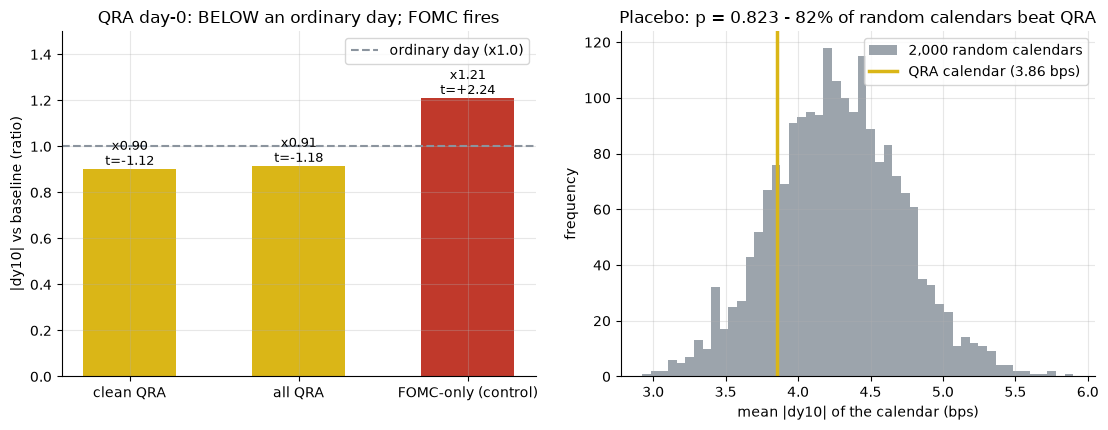

ratios: [('clean QRA', 0.9, -1.12), ('all QRA', 0.91, -1.18), ('FOMC-only (control)', 1.21, 2.24)]  placebo p = 0.823


In [2]:
if HAVE_REAL:
    s_c = st.day0_stats(DY, CLEAN, BASE)
    s_a = st.day0_stats(DY, ALLQ, BASE)
    qset = set(SP['qra_pos'])
    fpos = [p for p in st.event_positions(LIDX, data.FOMC_DATES) if p not in qset]
    s_f = st.day0_stats(DY, st.align_positions(LIDX, DY.index, fpos), BASE)
    pl = st.placebo_pvalue(DY, CLEAN, BASE, n_draws=2000, seed=607)
    rows = [('clean QRA', s_c['abs_ratio'], s_c['welch_abs']),
            ('all QRA', s_a['abs_ratio'], s_a['welch_abs']),
            ('FOMC-only (control)', s_f['abs_ratio'], s_f['welch_abs'])]
    obs, draws, pval = pl['obs'], pl['draws'], pl['p_value']
else:
    rows = [('clean QRA', R['day0_clean'][3], R['day0_clean'][4]),
            ('all QRA', R['day0_all'][3], R['day0_all'][4]),
            ('FOMC-only (control)', R['fomc_only'][2], R['fomc_only'][3])]
    obs, pval = R['day0_clean'][1], R['placebo_p']
    rng = np.random.default_rng(607); draws = rng.normal(R['placebo_draw_mean'], .35, 2000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
cols = [AMBER, AMBER, RED]
a1.bar([r[0] for r in rows], [r[1] for r in rows], color=cols, width=.55)
a1.axhline(1.0, ls='--', c=GREY, label='ordinary day (x1.0)')
for i, r in enumerate(rows): a1.annotate(f'x{r[1]:.2f}\nt={r[2]:+.2f}', (i, r[1]), ha='center', va='bottom', fontsize=9)
a1.set_ylabel('|dy10| vs baseline (ratio)'); a1.set_ylim(0, 1.5)
a1.set_title('QRA day-0: BELOW an ordinary day; FOMC fires'); a1.legend()
a2.hist(draws, bins=50, color=GREY, alpha=.85, label='2,000 random calendars')
a2.axvline(obs, color=AMBER, lw=2.5, label=f'QRA calendar ({obs:.2f} bps)')
a2.set_xlabel('mean |dy10| of the calendar (bps)'); a2.set_ylabel('frequency')
a2.set_title(f'Placebo: p = {pval:.3f} - 82% of random calendars beat QRA')
a2.legend(); plt.tight_layout(); plt.show()
print('ratios:', [(r[0], round(r[1],2), round(r[2],2)) for r in rows], ' placebo p =', round(pval,3))

> 💡 In plain words: on its own day the QRA moves the 10Y **3.86 bps** vs **4.28** on an ordinary day (×0.90, Welch *t* = -1.12; signed mean +0.03 bps, *t* = +0.05). The placebo says a random set of 69 days beats it 82% of the time. The same pipeline finds FOMC days at ×1.21 (*t* = +2.24) — the instrument works; the effect is absent. The 30Y agrees: ×1.10, *t* = +0.73.

### 4b · The window — and the jobs-report collision

Mean $|\Delta y_{10}|$ at offsets −1..+3 around clean QRA days. The +2 bump is the test case: QRA = early-month Wednesday ⇒ day+2 = first Friday = the Employment Situation, 08:30 ET.

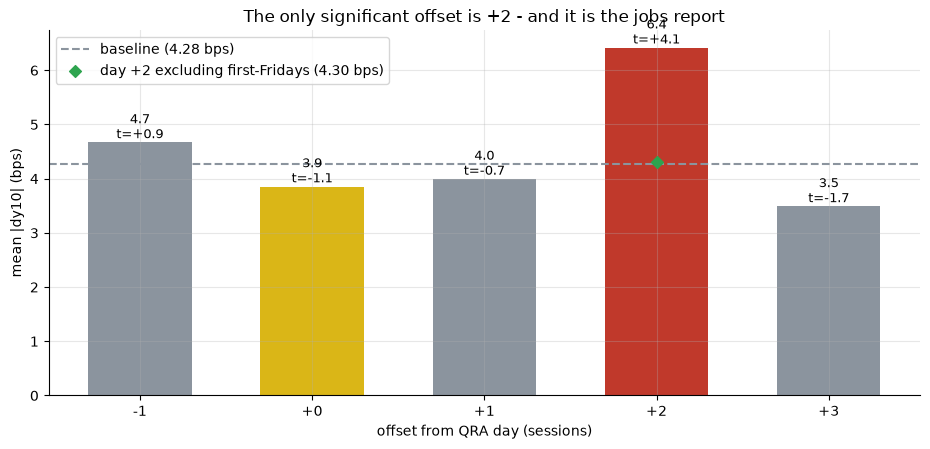

day+2: 63/69 are first-Fridays; excluding them |dy|=4.30 bps, Welch t=+0.01


In [3]:
if HAVE_REAL:
    prof = st.window_profile(DY, CLEAN, BASE)
    offs = [p['offset'] for p in prof]; vals = [p['abs_mean'] for p in prof]
    ts_ = [p['welch_abs'] for p in prof]; base = prof[0]['abs_base']
    dj = st.day2_jobs_diagnostic(DY, CLEAN, BASE)
else:
    offs = [w[0] for w in R['window']]; vals = [w[1] for w in R['window']]
    ts_ = [w[2] for w in R['window']]; base = R['day0_clean'][2]; dj = R['jobs']
    dj = dict(share_first_friday=dj['share_pct']/100, abs_ex_ff=dj['abs_ex'],
              welch_ex_ff=dj['welch_ex'], n_first_friday=dj['n_ff'], n_day2=dj['n_day2'])
fig, ax = plt.subplots(figsize=(9.4, 4.6))
cols = [RED if o == 2 else AMBER if o == 0 else GREY for o in offs]
ax.bar([f'{o:+d}' for o in offs], vals, color=cols, width=.6)
ax.axhline(base, ls='--', c=GREY, label=f'baseline ({base:.2f} bps)')
ax.scatter(['+2'], [dj['abs_ex_ff']], marker='D', color=GREEN, zorder=5,
           label=f"day +2 excluding first-Fridays ({dj['abs_ex_ff']:.2f} bps)")
for i, (v, t) in enumerate(zip(vals, ts_)):
    ax.annotate(f'{v:.1f}\nt={t:+.1f}', (i, v), ha='center', va='bottom', fontsize=9)
ax.set_xlabel('offset from QRA day (sessions)'); ax.set_ylabel('mean |dy10| (bps)')
ax.set_title('The only significant offset is +2 - and it is the jobs report')
ax.legend(); plt.tight_layout(); plt.show()
print(f"day+2: {dj['n_first_friday']}/{dj['n_day2']} are first-Fridays; excluding them "
      f"|dy|={dj['abs_ex_ff']:.2f} bps, Welch t={dj['welch_ex_ff']:+.2f}")

> 💡 In plain words: day+2 shows 6.42 bps (Welch *t* = +4.10) — but **63/69 (91%)** of those sessions are first-Friday Employment Situation releases. Exclude them and day+2 is 4.30 bps, Welch *t* = **+0.01**. The QRA window's lone "signal" is a calendar collision with the BLS — a textbook confound, and the same trap that makes 35% of QRA days FOMC days.

### 4c · H₃ — was 2023 a regime change?

Each day's $|\Delta y|$ normalised by its trailing 60-day mean (2023 days judged against 2023's own noise). Split at 2023-01-01 — the claim's own break date. n = 14 (7 FOMC-clean) since: small-n by construction, said out loud.

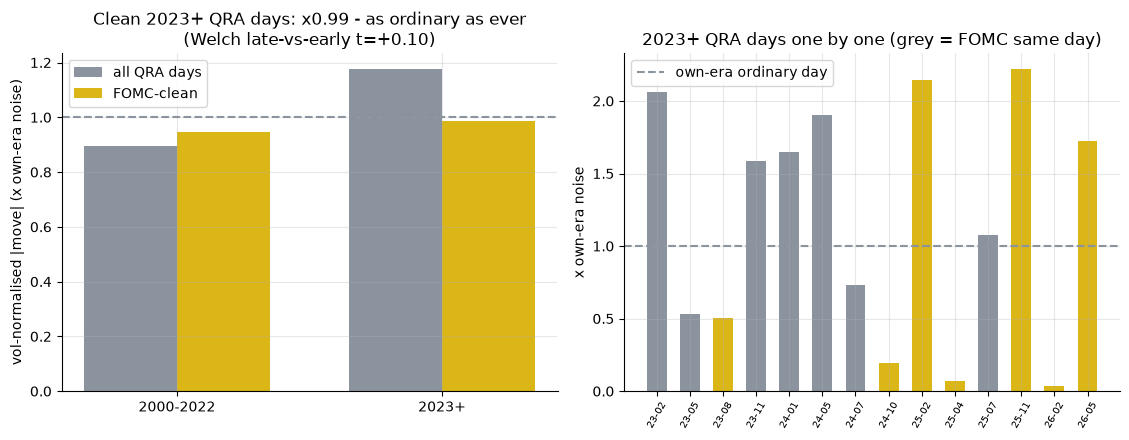

all-QRA: early 0.90x late 1.17x (welch +1.21); clean: early 0.95x late 0.99x (welch +0.10); drop Aug-2/Nov-1: 1.07x (welch +0.26)


In [4]:
if HAVE_REAL:
    ec_a = st.era_compare(DY, ALLQ, BASE, drop_dates=['2023-08-02', '2023-11-01'])
    ec_c = st.era_compare(DY, CLEAN, BASE, drop_dates=['2023-08-02', '2023-11-01'])
    A = dict(early=ec_a['norm_early'], late=ec_a['norm_late'], welch=ec_a['welch_late_vs_early'],
             trim=ec_a['norm_late_trim'], welch_trim=ec_a['welch_trim_vs_early'])
    C = dict(early=ec_c['norm_early'], late=ec_c['norm_late'], welch=ec_c['welch_late_vs_early'],
             trim=ec_c['norm_late_trim'], welch_trim=ec_c['welch_trim_vs_early'])
    late_dates, late_vals = ec_a['late_dates'], ec_a['late_norm_values']
else:
    A, C = R['era_all'], R['era_clean']
    late_dates = ['2023-02-01','2023-05-03','2023-08-02','2023-11-01','2024-01-31','2024-05-01',
                  '2024-07-31','2024-10-30','2025-02-05','2025-04-30','2025-07-30','2025-11-05',
                  '2026-02-04','2026-05-06']
    late_vals = [2.06,.54,.51,1.59,1.65,1.90,.73,.19,2.15,.07,1.08,2.22,.04,1.73]
fomc_set = set(data.FOMC_DATES)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.5))
x = np.arange(2); w = .35
a1.bar(x - w/2, [A['early'], A['late']], w, color=GREY, label='all QRA days')
a1.bar(x + w/2, [C['early'], C['late']], w, color=AMBER, label='FOMC-clean')
a1.axhline(1.0, ls='--', c=GREY)
a1.set_xticks(x); a1.set_xticklabels(['2000-2022', '2023+'])
a1.set_ylabel('vol-normalised |move| (x own-era noise)')
a1.set_title(f"Clean 2023+ QRA days: x{C['late']:.2f} - as ordinary as ever\n"
             f"(Welch late-vs-early t={C['welch']:+.2f})")
a1.legend()
cols = [GREY if d in fomc_set else AMBER for d in late_dates]
a2.bar(range(len(late_vals)), late_vals, color=cols, width=.6)
a2.axhline(1.0, ls='--', c=GREY, label='own-era ordinary day')
a2.set_xticks(range(len(late_dates)))
a2.set_xticklabels([d[2:7] for d in late_dates], rotation=60, fontsize=7)
a2.set_ylabel('x own-era noise')
a2.set_title('2023+ QRA days one by one (grey = FOMC same day)')
a2.legend(); plt.tight_layout(); plt.show()
print(f"all-QRA: early {A['early']:.2f}x late {A['late']:.2f}x (welch {A['welch']:+.2f}); "
      f"clean: early {C['early']:.2f}x late {C['late']:.2f}x (welch {C['welch']:+.2f}); "
      f"drop Aug-2/Nov-1: {C['trim']:.2f}x (welch {C['welch_trim']:+.2f})")

> 💡 In plain words: even judged against its own noisy era, a Fed-free 2023+ QRA day is a **0.99×** day — statistically identical to the 0.95× of 2000–2022 (Welch *t* = +0.10, n = 7 — small-n, so we claim only that *nothing detectable changed*). Dropping the two storied days **raises** the late mean to 1.07× — they weren't even loud on day-0 (Aug-2: 0.51×, +2.7 bps with Fitch in the tape; Nov-1: -8.6 bps with a same-day FOMC). The famous moves were week moves: +9.1 bps (Aug refunding week), -28.7 bps (Nov) — carried by downgrades, payrolls and the Fed as much as by Treasury.

### 4d · Tradability — TLT after the announcement

Entry at the day-0 close (the ONE lag — the statement is out at 08:30, the close is the first honest fill), exit +3 sessions. Unconditional and day-0-sign-conditional, gross and net.

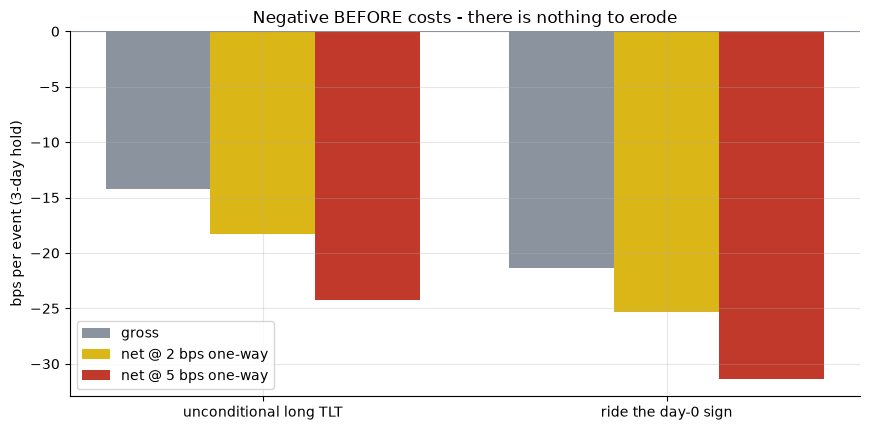

gross: [-14.3, -21.3]  net@2: [-18.3, -25.3]  net@5: [-24.3, -31.3]


In [5]:
if HAVE_REAL:
    tr = st.tlt_event_trades(TLT, data.QRA_DATES, hold=3)
    nets = [st.tlt_net(tr, cb) for cb in (2.0, 5.0)]
    g = [tr['uncond_mean_bps'], tr['cond_mean_bps']]
    n2 = [nets[0]['uncond_net_bps'], nets[0]['cond_net_bps']]
    n5 = [nets[1]['uncond_net_bps'], nets[1]['cond_net_bps']]
else:
    g = [R['tlt']['uncond'], R['tlt']['cond']]
    n2 = [R['tlt']['net'][0][1], R['tlt']['net'][0][3]]
    n5 = [R['tlt']['net'][1][1], R['tlt']['net'][1][3]]
x = np.arange(2); w = .26
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x - w, g, w, color=GREY, label='gross')
ax.bar(x, n2, w, color=AMBER, label='net @ 2 bps one-way')
ax.bar(x + w, n5, w, color=RED, label='net @ 5 bps one-way')
ax.axhline(0, color=GREY)
ax.set_xticks(x); ax.set_xticklabels(['unconditional long TLT', 'ride the day-0 sign'])
ax.set_ylabel('bps per event (3-day hold)')
ax.set_title('Negative BEFORE costs - there is nothing to erode')
ax.legend(); plt.tight_layout(); plt.show()
print('gross:', [round(v,1) for v in g], ' net@2:', [round(v,1) for v in n2],
      ' net@5:', [round(v,1) for v in n5])

> 💡 In plain words: 96 events, ~4/yr. Unconditional: **-14.3 bps/event** gross (*t* = -0.89; ordinary 3-day windows average +4.6 bps — the post-QRA windows are insignificantly *worse*, Welch *t* = -1.15). Conditional continuation: **-21.3 bps/event** (*t* = -1.33). Net at 2/5 bps one-way: −73 to −126 bps/yr. MIRAGE — there was never anything to pay costs *from*.

### 4e · Synthetic power control — the machinery is faithful

A deterministic pseudo-QRA world (i.i.d. daily Δy, events every 63 sessions) with two knobs: an event-day **vol multiplier** and a **signed event-day mean**. The null must stay quiet; each planted effect must light its own detector. *(Machinery proof only — never cited as market evidence.)*

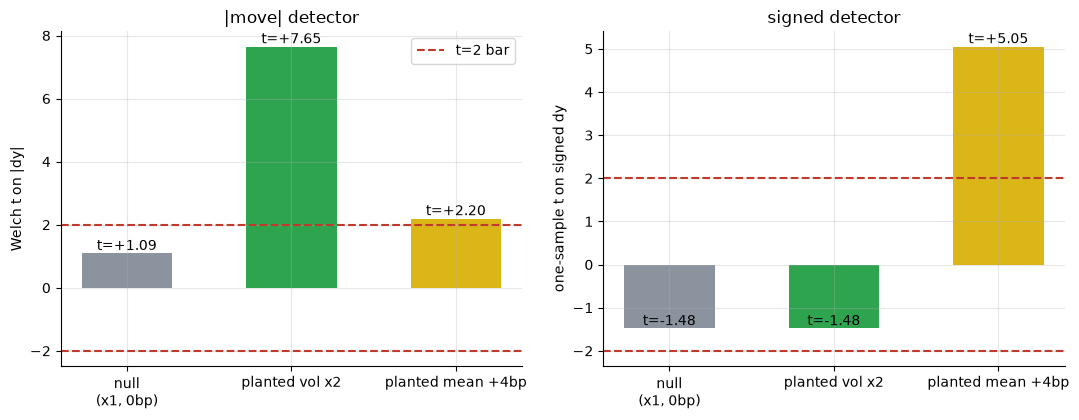

vol x1.0 mean +0.0bp: ratio x1.08 welch +1.09 signed t -1.48
vol x2.0 mean +0.0bp: ratio x2.17 welch +7.65 signed t -1.48
vol x1.0 mean +4.0bp: ratio x1.19 welch +2.20 signed t +5.05


In [6]:
res = []
for vol_mult, mean_bp in [(1.0, 0.0), (2.0, 0.0), (1.0, 4.0)]:
    lvl, ev = data.synthetic_world(vol_mult=vol_mult, mean_bp=mean_bp, seed=607)
    dys = st.dy_bps(lvl); li = pd.DatetimeIndex(lvl.index)
    sps = st.clean_split(li, ev, [])
    ps = st.align_positions(li, dys.index, sps['clean_pos'])
    s = st.day0_stats(dys, ps, sps['base_mask'][1:])
    res.append((vol_mult, mean_bp, s['abs_ratio'], s['welch_abs'], s['t_signed']))
labs = [f'null\n(x1, 0bp)', f'planted vol x2', f'planted mean +4bp']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(labs, [r[3] for r in res], color=[GREY, GREEN, AMBER], width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 bar'); a1.axhline(-2, ls='--', c=RED)
for i, r in enumerate(res): a1.annotate(f't={r[3]:+.2f}', (i, r[3]), ha='center', va='bottom')
a1.set_ylabel('Welch t on |dy|'); a1.set_title('|move| detector'); a1.legend()
a2.bar(labs, [r[4] for r in res], color=[GREY, GREEN, AMBER], width=.55)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED)
for i, r in enumerate(res): a2.annotate(f't={r[4]:+.2f}', (i, r[4]), ha='center', va='bottom')
a2.set_ylabel('one-sample t on signed dy'); a2.set_title('signed detector')
plt.tight_layout(); plt.show()
for r in res: print(f'vol x{r[0]:.1f} mean {r[1]:+.1f}bp: ratio x{r[2]:.2f} welch {r[3]:+.2f} signed t {r[4]:+.2f}')

> 💡 In plain words: the null sits at Welch *t* = +1.09 (no false alarm); a planted ×2 vol day fires at *t* = +7.65; a planted +4 bp drift fires the signed detector at *t* = +5.05. Together with the in-tape FOMC control (×1.21, *t* = +2.24), the instruments are proven sharp — the real-tape nulls are genuine absences.

## 5 · The verdict

- **Signal `NONE`** — clean QRA day-0 |Δy10| **3.86 bps vs 4.28 baseline** (×0.90, Welch *t* = -1.12; placebo p = 0.82); 30Y ×1.10 (*t* = +0.73); signed drift nil. The lone window bump (day+2, *t* = +4.10) is the jobs report (91% first-Fridays; without them *t* = +0.01). The pipeline detects FOMC days (×1.21, *t* = +2.24) — the absence is real, not instrumental. No survivorship.
- **Tradability `MIRAGE`** — TLT legs: -14.3 (unconditional) and -21.3 (conditional) bps/event **gross**; −73 to −126 bps/yr net. Nothing exists to harvest.
- **2023 regime change? `BUSTED`** — vol-normalised clean QRA days: 2023+ 0.99× vs 0.95× pre-2023 (Welch *t* = +0.10; n = 7, small-n stated). Aug-2/Nov-1 2023 were small on day-0 and confounded (Fitch; same-day FOMC); the legend is two loud weeks, not a new event class.

## 6 · Going further

- **The supply effect lives at the auctions, not the announcement.** Sibling [603-treasury-auction-concession](../../603-treasury-auction-concession/README.md) finds a real, HAC-significant concession *into* the 10Y/30Y auctions — the dealers get paid to absorb the bonds, not to hear the plan. Announcement ≠ absorption.
- **Anticipation is the null hypothesis for policy calendars.** Treasury surveys primary dealers before every refunding and telegraphs changes; the information is mostly in prices by 08:30. Contrast FOMC days, where a genuine surprise component survives — and shows up in our control.
- **What would overturn us.** Intraday (08:30–09:30) reaction windows; the Monday borrowing-estimate days as separate events; survey-based size surprises (dealer medians vs announced sizes) as a signed regressor. The harness accepts any date table — the QRA list is hardcoded with its derivation.

*Reproducible core: offline and deterministic; event table + FOMC calendar hardcoded with sources. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*